# GitHub Projects Data Analytics Pipeline

Level 3 Project 2

## Task 1: Data Collection & Preparation

### Step 1: Collect data from the GitHub API

In [1]:
import requests
import pandas as pd

In [2]:
# search endpoint for machine learning repos, sorted by stars
api_url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"

In [3]:
response = requests.get(api_url)
response.raise_for_status()

data = response.json()

In [4]:
print("Total repos found:", data["total_count"])
print("Repos returned:", len(data["items"]))

Total repos found: 1234345
Repos returned: 100


### Step 2: Create the DataFrame and explore it

In [5]:
# flatten the nested json into a table
df = pd.json_normalize(data["items"])
df.shape

(100, 105)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Columns: 105 entries, id to license
dtypes: bool(15), float64(2), int64(10), object(2), str(76)
memory usage: 71.9+ KB


In [7]:
df.head()

,id,node_id,name,full_name,private,html_url,description,fork,url,forks_url,...,owner.received_events_url,owner.type,owner.user_view_type,owner.site_admin,license.key,license.name,license.spdx_id,license.url,license.node_id,license
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,https://api.github.com/repos/tensorflow/tensor...,...,https://api.github.com/users/tensorflow/receiv...,Organization,public,False,apache-2.0,Apache License 2.0,Apache-2.0,https://api.github.com/licenses/apache-2.0,MDc6TGljZW5zZTI=,NaN
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,https://api.github.com/repos/huggingface/trans...,...,https://api.github.com/users/huggingface/recei...,Organization,public,False,apache-2.0,Apache License 2.0,Apache-2.0,https://api.github.com/licenses/apache-2.0,MDc6TGljZW5zZTI=,NaN
2,343965132,MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=,ML-For-Beginners,microsoft/ML-For-Beginners,False,https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",False,https://api.github.com/repos/microsoft/ML-For-...,https://api.github.com/repos/microsoft/ML-For-...,...,https://api.github.com/users/microsoft/receive...,Organization,public,False,mit,MIT License,MIT,https://api.github.com/licenses/mit,MDc6TGljZW5zZTEz,NaN
3,145553672,MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=,funNLP,fighting41love/funNLP,False,https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,False,https://api.github.com/repos/fighting41love/fu...,https://api.github.com/repos/fighting41love/fu...,...,https://api.github.com/users/fighting41love/re...,User,public,False,NaN,NaN,NaN,NaN,NaN,NaN
4,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,https://api.github.com/repos/josephmisiti/awes...,...,https://api.github.com/users/josephmisiti/rece...,User,public,False,other,Other,NOASSERTION,NaN,MDc6TGljZW5zZTA=,NaN


### Step 3: Select the required columns

In [8]:
columns_needed = [
    "name", "full_name", "owner.login", "html_url", "description",
    "language", "stargazers_count", "forks_count", "open_issues_count",
    "created_at", "updated_at", "license.name"
]

df = df[columns_needed].copy()

In [9]:
# rename nested columns to something simpler
df = df.rename(columns={
    "owner.login": "owner",
    "license.name": "license"
})

df.head()

,name,full_name,owner,html_url,description,language,stargazers_count,forks_count,open_issues_count,created_at,updated_at,license
0,tensorflow,tensorflow/tensorflow,tensorflow,https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,C++,197213,76081,2942,2015-11-07T01:19:20Z,2026-08-21T09:00:06Z,Apache License 2.0
1,transformers,huggingface/transformers,huggingface,https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,Python,164294,34305,2401,2018-10-29T13:56:00Z,2026-08-21T08:46:57Z,Apache License 2.0
2,ML-For-Beginners,microsoft/ML-For-Beginners,microsoft,https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",Jupyter Notebook,89641,22014,14,2021-03-03T01:34:05Z,2026-08-21T08:37:15Z,MIT License
3,funNLP,fighting41love/funNLP,fighting41love,https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,Python,82576,15271,52,2018-08-21T11:20:39Z,2026-08-21T08:42:18Z,NaN
4,awesome-machine-learning,josephmisiti/awesome-machine-learning,josephmisiti,https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,Python,74093,15617,27,2014-07-15T19:11:19Z,2026-08-21T08:39:29Z,Other


### Step 4: Handle missing values

In [10]:
df.isnull().sum()

name                  0
full_name             0
owner                 0
html_url              0
description           0
language             23
stargazers_count      0
forks_count           0
open_issues_count     0
created_at            0
updated_at            0
license              22
dtype: int64

In [11]:
# fill missing values instead of dropping rows
df["description"] = df["description"].fillna("No description")
df["license"] = df["license"].fillna("No license")
df["language"] = df["language"].fillna("Unknown")

In [12]:
# drop rows only if the name is missing
df = df.dropna(subset=["name", "full_name"])

### Step 5: Handle duplicate records

In [13]:
before = len(df)
df = df.drop_duplicates(subset=["full_name"])
after = len(df)

print("Duplicates removed:", before - after)

Duplicates removed: 0


### Step 6: Prepare the dataset for SQL

In [14]:
# convert date columns to datetime
df["created_at"] = pd.to_datetime(df["created_at"])
df["updated_at"] = pd.to_datetime(df["updated_at"])

In [15]:
# rename columns to simpler SQL friendly names
df = df.rename(columns={
    "stargazers_count": "stars",
    "forks_count": "forks",
    "open_issues_count": "open_issues"
})

df.dtypes

name                           str
full_name                      str
owner                          str
html_url                       str
description                    str
language                       str
stars                        int64
forks                        int64
open_issues                  int64
created_at     datetime64[us, UTC]
updated_at     datetime64[us, UTC]
license                        str
dtype: object

### Step 7: Save and verify the dataset

In [16]:
df.to_csv("github_projects.csv", index=False)

In [17]:
# reload the file to check it saved correctly
check = pd.read_csv("github_projects.csv")
print("Saved correctly:", check.shape == df.shape)
check.head()

Saved correctly: True


,name,full_name,owner,html_url,description,language,stars,forks,open_issues,created_at,updated_at,license
0,tensorflow,tensorflow/tensorflow,tensorflow,https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,C++,197213,76081,2942,2015-11-07 01:19:20+00:00,2026-08-21 09:00:06+00:00,Apache License 2.0
1,transformers,huggingface/transformers,huggingface,https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,Python,164294,34305,2401,2018-10-29 13:56:00+00:00,2026-08-21 08:46:57+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft/ML-For-Beginners,microsoft,https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",Jupyter Notebook,89641,22014,14,2021-03-03 01:34:05+00:00,2026-08-21 08:37:15+00:00,MIT License
3,funNLP,fighting41love/funNLP,fighting41love,https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,Python,82576,15271,52,2018-08-21 11:20:39+00:00,2026-08-21 08:42:18+00:00,No license
4,awesome-machine-learning,josephmisiti/awesome-machine-learning,josephmisiti,https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,Python,74093,15617,27,2014-07-15 19:11:19+00:00,2026-08-21 08:39:29+00:00,Other


## Task 2: Store & Analyse the Data

### Step 8: Create the SQLite database

In [18]:
import sqlite3

conn = sqlite3.connect("github_projects.db")

In [19]:
df.to_sql("Repositories", conn, if_exists="replace", index=False)

100

In [20]:
# check the table has data in it
pd.read_sql("SELECT * FROM Repositories LIMIT 5", conn)

,name,full_name,owner,html_url,description,language,stars,forks,open_issues,created_at,updated_at,license
0,tensorflow,tensorflow/tensorflow,tensorflow,https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,C++,197213,76081,2942,2015-11-07 01:19:20+00:00,2026-08-21 09:00:06+00:00,Apache License 2.0
1,transformers,huggingface/transformers,huggingface,https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,Python,164294,34305,2401,2018-10-29 13:56:00+00:00,2026-08-21 08:46:57+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft/ML-For-Beginners,microsoft,https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",Jupyter Notebook,89641,22014,14,2021-03-03 01:34:05+00:00,2026-08-21 08:37:15+00:00,MIT License
3,funNLP,fighting41love/funNLP,fighting41love,https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,Python,82576,15271,52,2018-08-21 11:20:39+00:00,2026-08-21 08:42:18+00:00,No license
4,awesome-machine-learning,josephmisiti/awesome-machine-learning,josephmisiti,https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,Python,74093,15617,27,2014-07-15 19:11:19+00:00,2026-08-21 08:39:29+00:00,Other


### Step 9: SQL analysis

Filtering and searching

In [21]:
pd.read_sql("""
    SELECT name, owner, stars
    FROM Repositories
    WHERE language = 'Python' AND stars > 5000
""", conn)

,name,owner,stars
0,transformers,huggingface,164294
1,funNLP,fighting41love,82576
2,awesome-machine-learning,josephmisiti,74093
3,scikit-learn,scikit-learn,66988
4,gradio,gradio-app,43394
5,ML-From-Scratch,eriklindernoren,32500
6,linkedin-skill-assessments-quizzes,Ebazhanov,28805
7,cs249r_book,harvard-edge,27968
8,onnx,onnx,21340
9,rasa,RasaHQ,21298


Logical operators

In [22]:
pd.read_sql("""
    SELECT name, language, stars
    FROM Repositories
    WHERE (language = 'Python' OR language = 'Jupyter Notebook')
    AND NOT license = 'No license'
""", conn)

,name,language,stars
0,transformers,Python,164294
1,ML-For-Beginners,Jupyter Notebook,89641
2,awesome-machine-learning,Python,74093
3,scikit-learn,Python,66988
4,gradio,Python,43394
5,ML-From-Scratch,Python,32500
6,linkedin-skill-assessments-quizzes,Python,28805
7,cs249r_book,Python,27968
8,shap,Jupyter Notebook,25692
9,homemade-machine-learning,Jupyter Notebook,24771


Sorting and limiting

In [23]:
pd.read_sql("""
    SELECT name, stars
    FROM Repositories
    ORDER BY stars DESC
    LIMIT 10
""", conn)

,name,stars
0,tensorflow,197213
1,transformers,164294
2,ML-For-Beginners,89641
3,funNLP,82576
4,awesome-machine-learning,74093
5,scikit-learn,66988
6,gradio,43394
7,500-AI-Machine-learning-Deep-learning-Computer...,36424
8,C-Plus-Plus,34590
9,netron,33377


Aggregate functions

In [24]:
pd.read_sql("""
    SELECT COUNT(*) AS total_repos, AVG(stars) AS avg_stars, MAX(stars) AS max_stars
    FROM Repositories
""", conn)

,total_repos,avg_stars,max_stars
0,100,20816.31,197213


Grouping

In [25]:
pd.read_sql("""
    SELECT language, COUNT(*) AS repo_count, AVG(stars) AS avg_stars
    FROM Repositories
    GROUP BY language
    HAVING COUNT(*) > 1
    ORDER BY avg_stars DESC
""", conn)

,language,repo_count,avg_stars
0,C++,12,32201.666667
1,Python,30,26560.333333
2,JavaScript,3,20601.666667
3,Jupyter Notebook,19,17096.631579
4,Unknown,23,15640.304348
5,C#,2,14495.500000
6,HTML,2,11733.500000
7,Go,3,8969.333333


### Step 10: Create visualizations

In [26]:
import matplotlib.pyplot as plt

Chart 1: Top 10 repos by stars

In [27]:
top10 = pd.read_sql("""
    SELECT name, stars FROM Repositories ORDER BY stars DESC LIMIT 10
""", conn)

In [28]:
# shorten long repo names so the chart is readable
short_names = []

for name in top10["name"]:
    if len(name) > 15:
        name = name[:15] + "..."
    short_names.append(name)

top10["short_name"] = short_names

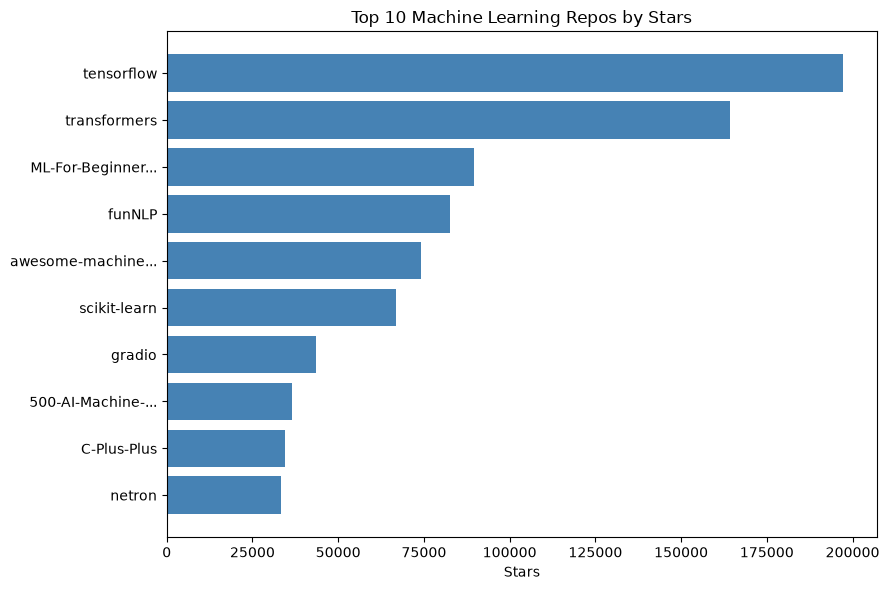

In [29]:
plt.figure(figsize=(9, 6))
plt.barh(top10["short_name"], top10["stars"], color="steelblue")
plt.xlabel("Stars")
plt.title("Top 10 Machine Learning Repos by Stars")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("top10_stars.png")
plt.show()

Chart 2: Repos by language

In [30]:
lang_counts = pd.read_sql("""
    SELECT language, COUNT(*) AS count FROM Repositories GROUP BY language
""", conn)

lang_counts = lang_counts.sort_values("count", ascending=False)

In [31]:
# combine small language groups into "Other" so the pie chart is readable
top_langs = lang_counts.head(5).copy()

other_count = 0
for count in lang_counts["count"][5:]:
    other_count = other_count + count

if other_count > 0:
    other_row = pd.DataFrame({"language": ["Other"], "count": [other_count]})
    top_langs = pd.concat([top_langs, other_row], ignore_index=True)

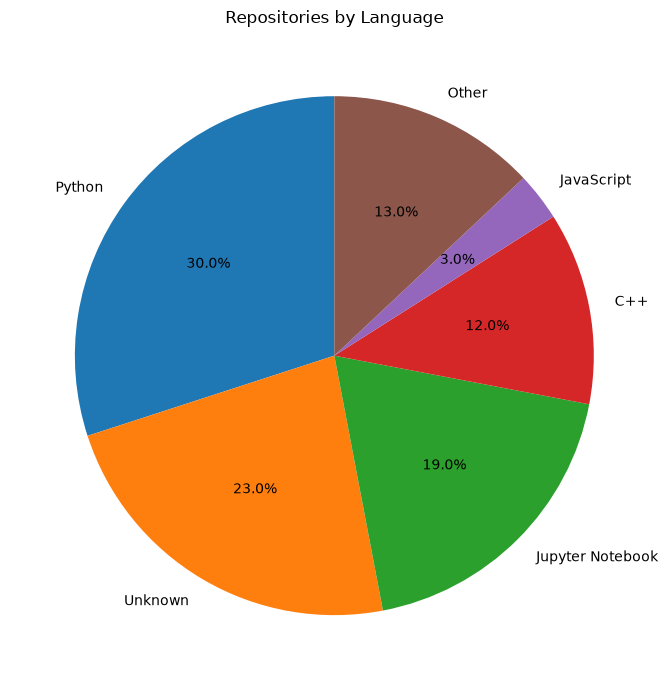

In [32]:
plt.figure(figsize=(7, 7))
plt.pie(top_langs["count"], labels=top_langs["language"], autopct="%1.1f%%", startangle=90)
plt.title("Repositories by Language")
plt.tight_layout()
plt.savefig("language_pie.png")
plt.show()

Chart 3: Repos created by year

In [33]:
df["created_year"] = df["created_at"].dt.year
year_counts = df.groupby("created_year").size().reset_index(name="count")

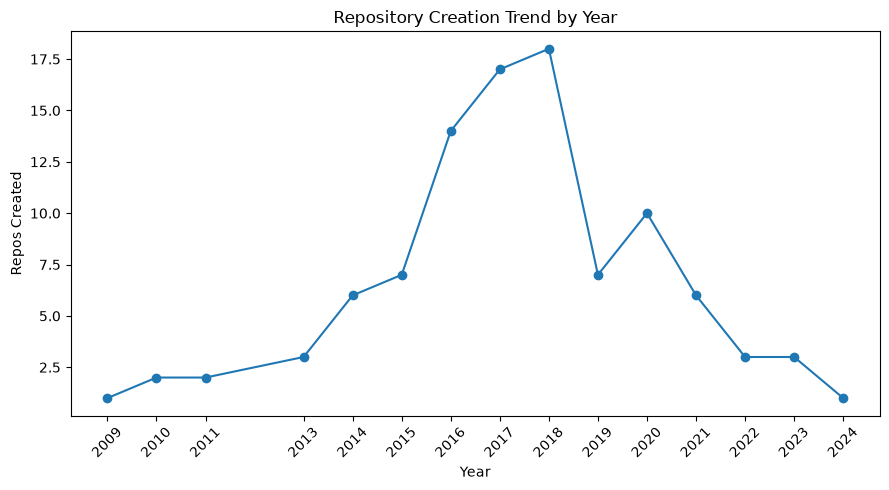

In [34]:
plt.figure(figsize=(9, 5))
plt.plot(year_counts["created_year"], year_counts["count"], marker="o")
plt.xlabel("Year")
plt.ylabel("Repos Created")
plt.title("Repository Creation Trend by Year")
plt.xticks(year_counts["created_year"], rotation=45)
plt.tight_layout()
plt.savefig("creation_trend.png")
plt.show()

### Step 11: Interpret results

- The top 10 chart shows a small number of repositories have far more stars than the rest.
- Python is the most common language in the dataset, which fits with machine learning being a Python-heavy field.
- The creation trend shows most repositories were created in recent years, matching the growth of interest in machine learning.


## Task 3: Version Control & Project Ethics

### Ethics Reflection

**Question 1: Why is it important to verify data collected from public APIs?**
Public APIs can return data that is incomplete, outdated, or incorrect. Verifying the data makes sure the analysis is based on accurate information and not on errors that came from the source itself.

**Question 2: Why should data analysts document the source of their data?**
Documenting the source lets other people check where the data came from, repeat the same collection process, and trust that the analysis can be verified. It also makes the work more transparent.

**Question 3: How can missing or inaccurate data affect data analysis and decision-making?**
Missing or inaccurate data can lead to wrong conclusions and charts that do not represent reality. If decisions are made based on this data, they may be based on a false picture of the situation, which can lead to poor outcomes.

GitHub Repository: https://github.com/mohaM4e/lv3_deci_project.git